# 📊 Análisis de Ventas — E-commerce (Online Retail)

Este notebook realiza un **análisis completo de las métricas más destacables de ventas** de un comercio electrónico (dataset *Online Retail*, transacciones de un retailer online del Reino Unido entre **dic-2010 y dic-2011**).

**Objetivo:** generar información accionable para la toma de decisiones comerciales, mediante:

1. Limpieza y preparación de los datos
2. KPIs generales del negocio
3. Análisis de tendencia temporal de ventas
4. Análisis de productos (más y menos vendidos)
5. Análisis geográfico (países)
6. Análisis de clientes (RFM y segmentación)
7. Análisis de devoluciones/cancelaciones
8. Conclusiones y recomendaciones estratégicas

---


## 1. Carga de librerías y datos

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import timedelta

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
pd.options.display.float_format = '{:,.2f}'.format

%matplotlib inline


In [9]:
# Carga del dataset
df = pd.read_excel('../data/raw/Online Retail.xlsx')
print(f"Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head()


Dimensiones del dataset: 541,909 filas x 8 columnas


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [10]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


## 2. Limpieza y preparación de datos

Se identifican y tratan los siguientes problemas comunes en este tipo de datasets:
- Valores nulos en `CustomerID` y `Description`
- Cantidades negativas (`Quantity < 0`) que corresponden a **devoluciones**
- Facturas canceladas (prefijo `C` en `InvoiceNo`)
- Precios unitarios en cero o negativos (errores de registro)


In [11]:
# Resumen de valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\n% de filas sin CustomerID: {df['CustomerID'].isnull().mean()*100:.2f}%")


Valores nulos por columna:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

% de filas sin CustomerID: 24.93%


In [12]:
# Marcar transacciones canceladas/devoluciones
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df['EsCancelacion'] = df['InvoiceNo'].str.startswith('C')

print(f"Facturas canceladas: {df['EsCancelacion'].sum():,} ({df['EsCancelacion'].mean()*100:.2f}%)")
print(f"Registros con cantidad negativa: {(df['Quantity'] < 0).sum():,}")
print(f"Registros con precio <= 0: {(df['UnitPrice'] <= 0).sum():,}")


Facturas canceladas: 9,288 (1.71%)
Registros con cantidad negativa: 10,624
Registros con precio <= 0: 2,517


In [13]:
# Dataset limpio para análisis de VENTAS (excluye cancelaciones, cantidades <=0 y precios <=0)
df_ventas = df[
    (~df['EsCancelacion']) &
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
].copy()

# Columna de importe total por línea
df_ventas['ImporteTotal'] = df_ventas['Quantity'] * df_ventas['UnitPrice']

# Variables temporales útiles
df_ventas['Fecha'] = df_ventas['InvoiceDate'].dt.date
df_ventas['Anio'] = df_ventas['InvoiceDate'].dt.year
df_ventas['Mes'] = df_ventas['InvoiceDate'].dt.month
df_ventas['AnioMes'] = df_ventas['InvoiceDate'].dt.to_period('M').astype(str)
df_ventas['DiaSemana'] = df_ventas['InvoiceDate'].dt.day_name()
df_ventas['Hora'] = df_ventas['InvoiceDate'].dt.hour

print(f"Registros válidos de ventas: {len(df_ventas):,} de {len(df):,} originales ({len(df_ventas)/len(df)*100:.1f}%)")
df_ventas.head()


Registros válidos de ventas: 530,104 de 541,909 originales (97.8%)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,EsCancelacion,ImporteTotal,Fecha,Anio,Mes,AnioMes,DiaSemana,Hora
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,False,15.30,2010-12-01,2010,12,2010-12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,False,20.34,2010-12-01,2010,12,2010-12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,False,22.00,2010-12-01,2010,12,2010-12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,False,20.34,2010-12-01,2010,12,2010-12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,False,20.34,2010-12-01,2010,12,2010-12,Wednesday,8


## 3. KPIs generales del negocio

In [14]:
ingresos_totales = df_ventas['ImporteTotal'].sum()
num_pedidos = df_ventas['InvoiceNo'].nunique()
num_clientes = df_ventas['CustomerID'].nunique()
num_productos = df_ventas['StockCode'].nunique()
ticket_promedio = ingresos_totales / num_pedidos
unidades_vendidas = df_ventas['Quantity'].sum()
paises = df_ventas['Country'].nunique()

fecha_inicio = df_ventas['InvoiceDate'].min().date()
fecha_fin = df_ventas['InvoiceDate'].max().date()

print("="*55)
print("        📌 KPIs GENERALES DEL NEGOCIO")
print("="*55)
print(f"Periodo analizado:        {fecha_inicio} a {fecha_fin}")
print(f"Ingresos totales:         £{ingresos_totales:,.2f}")
print(f"N° de pedidos (invoices): {num_pedidos:,}")
print(f"Ticket promedio:          £{ticket_promedio:,.2f}")
print(f"Unidades vendidas:        {unidades_vendidas:,}")
print(f"Clientes únicos:          {num_clientes:,}")
print(f"Productos únicos (SKU):   {num_productos:,}")
print(f"Países atendidos:         {paises}")
print("="*55)


        📌 KPIs GENERALES DEL NEGOCIO
Periodo analizado:        2010-12-01 a 2011-12-09
Ingresos totales:         £10,666,684.54
N° de pedidos (invoices): 19,960
Ticket promedio:          £534.40
Unidades vendidas:        5,588,376
Clientes únicos:          4,338
Productos únicos (SKU):   3,922
Países atendidos:         38


In [15]:
# Valor de devoluciones/cancelaciones (impacto negativo)
df_cancelado = df[df['EsCancelacion']].copy()
df_cancelado['ImporteTotal'] = df_cancelado['Quantity'] * df_cancelado['UnitPrice']
valor_cancelado = abs(df_cancelado['ImporteTotal'].sum())
tasa_cancelacion = df_cancelado['InvoiceNo'].nunique() / df['InvoiceNo'].nunique() * 100

print(f"Valor total de devoluciones/cancelaciones: £{valor_cancelado:,.2f}")
print(f"Tasa de cancelación de pedidos: {tasa_cancelacion:.2f}%")
print(f"Esto representa el {valor_cancelado/ingresos_totales*100:.2f}% de los ingresos brutos")


Valor total de devoluciones/cancelaciones: £896,812.49
Tasa de cancelación de pedidos: 14.81%
Esto representa el 8.41% de los ingresos brutos


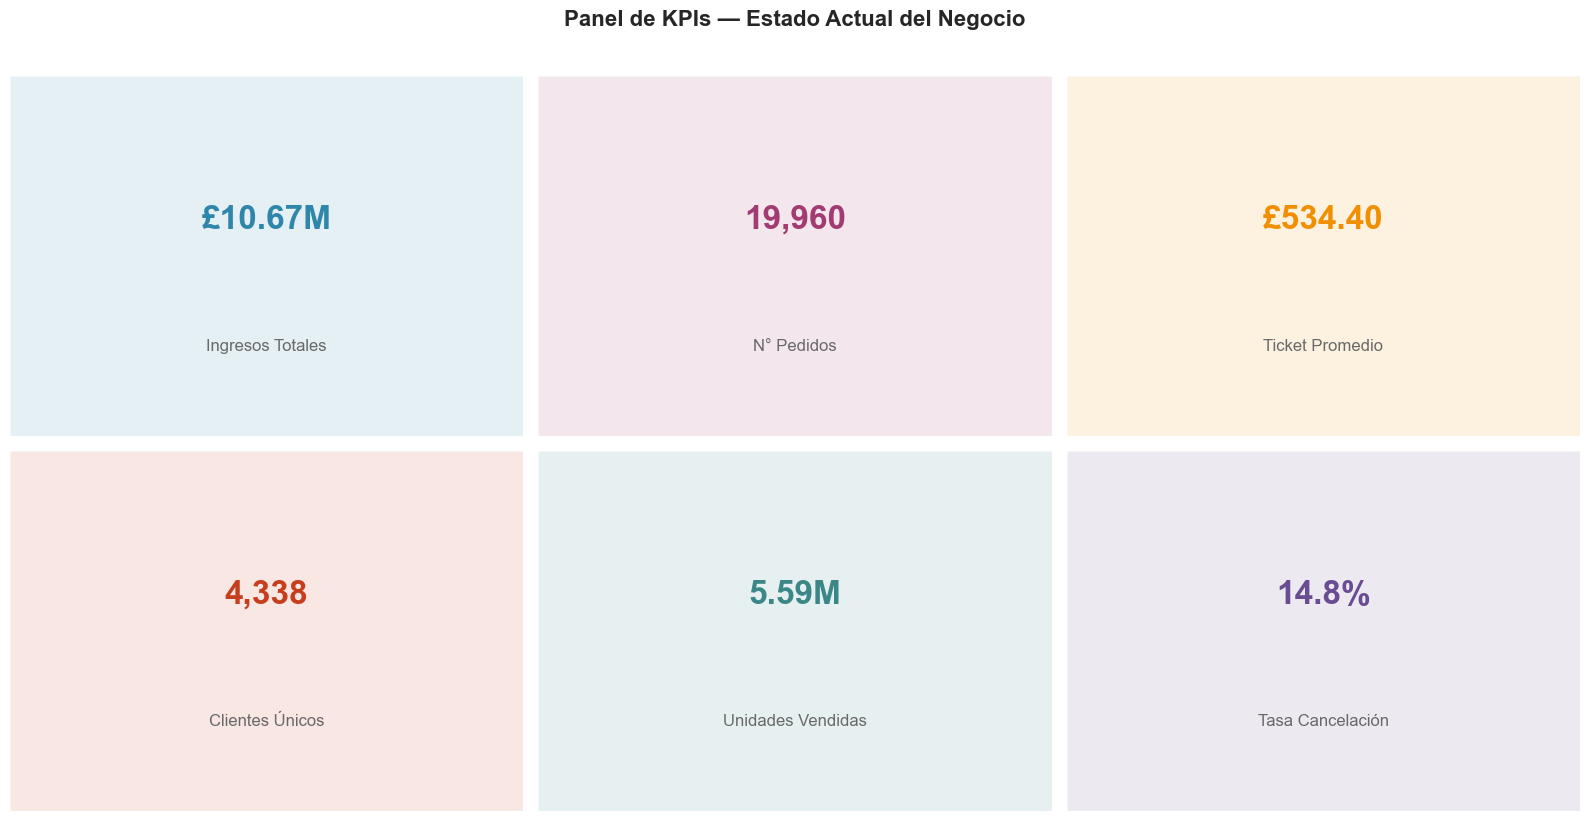

In [16]:
# Panel resumen visual de KPIs
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
kpis = [
    ("Ingresos Totales", f"£{ingresos_totales/1e6:,.2f}M", '#2E86AB'),
    ("N° Pedidos", f"{num_pedidos:,}", '#A23B72'),
    ("Ticket Promedio", f"£{ticket_promedio:,.2f}", '#F18F01'),
    ("Clientes Únicos", f"{num_clientes:,}", '#C73E1D'),
    ("Unidades Vendidas", f"{unidades_vendidas/1e6:,.2f}M", '#3B8686'),
    ("Tasa Cancelación", f"{tasa_cancelacion:.1f}%", '#6A4C93'),
]
for ax, (titulo, valor, color) in zip(axes.flat, kpis):
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0,0), 1, 1, transform=ax.transAxes, facecolor=color, alpha=0.12))
    ax.text(0.5, 0.6, valor, fontsize=24, ha='center', va='center', fontweight='bold', color=color)
    ax.text(0.5, 0.25, titulo, fontsize=12, ha='center', va='center', color='dimgray')
plt.suptitle('Panel de KPIs — Estado Actual del Negocio', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 4. Tendencia temporal de ventas

Analizamos la evolución de los ingresos para identificar estacionalidad, crecimiento y patrones de comportamiento en el tiempo.


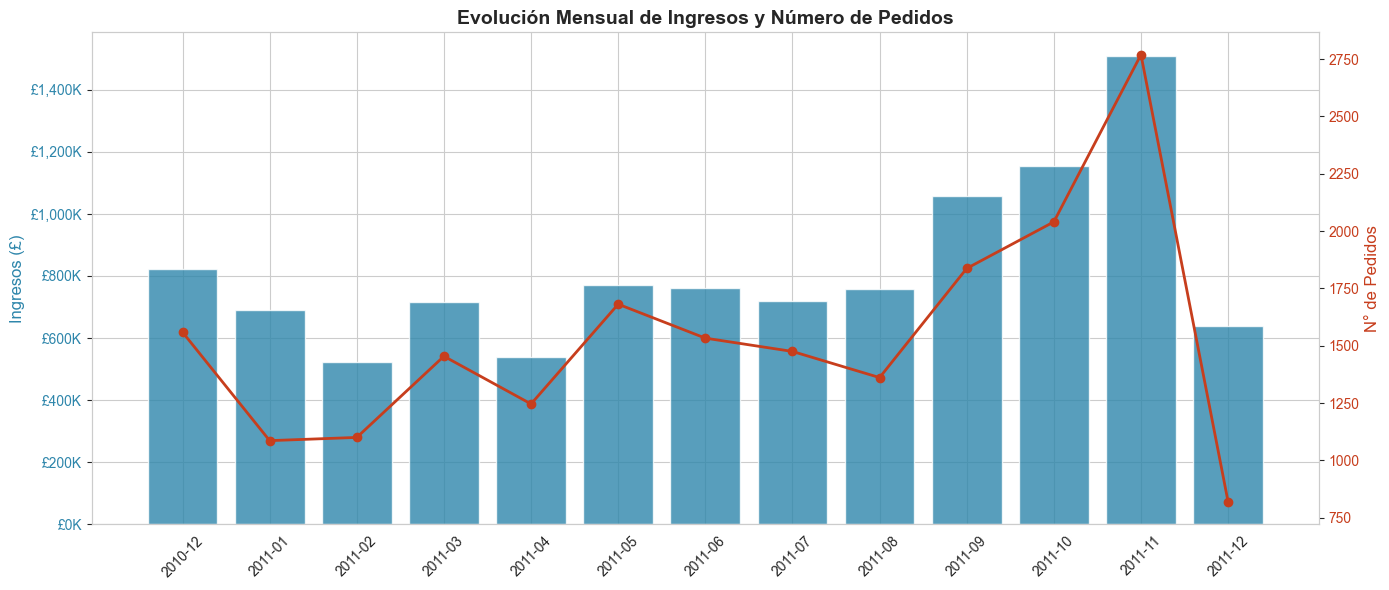

💡 Nota: diciembre de 2011 solo contiene datos hasta el día 9, por lo que su caída no refleja necesariamente una baja real de demanda.


In [17]:
ventas_mensuales = df_ventas.groupby('AnioMes').agg(
    Ingresos=('ImporteTotal', 'sum'),
    Pedidos=('InvoiceNo', 'nunique')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(ventas_mensuales['AnioMes'], ventas_mensuales['Ingresos'], color='#2E86AB', alpha=0.8, label='Ingresos')
ax1.set_ylabel('Ingresos (£)', color='#2E86AB', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'£{x/1000:,.0f}K'))
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.plot(ventas_mensuales['AnioMes'], ventas_mensuales['Pedidos'], color='#C73E1D', marker='o', linewidth=2, label='Pedidos')
ax2.set_ylabel('N° de Pedidos', color='#C73E1D', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#C73E1D')
ax2.grid(False)

plt.title('Evolución Mensual de Ingresos y Número de Pedidos')
fig.tight_layout()
plt.show()

print("💡 Nota: diciembre de 2011 solo contiene datos hasta el día 9, por lo que su caída no refleja necesariamente una baja real de demanda.")


C:\Users\dhduq\AppData\Local\Temp\ipykernel_4660\1281165202.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_dia.index, y=ventas_dia.values, ax=axes[0], palette='Blues_d')


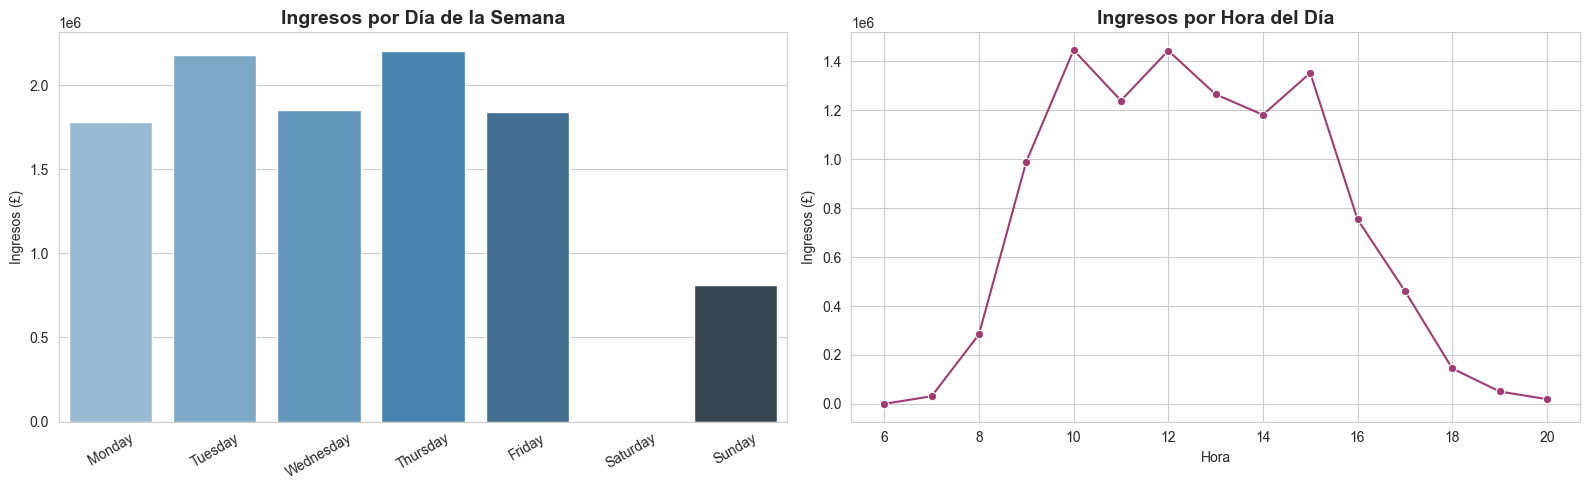

💡 Nota: no hay ventas registradas los sábados en este dataset (particularidad operativa del comercio).


In [18]:
# Estacionalidad: ventas por día de la semana y por hora
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ventas_dia = df_ventas.groupby('DiaSemana')['ImporteTotal'].sum().reindex(orden_dias)
sns.barplot(x=ventas_dia.index, y=ventas_dia.values, ax=axes[0], palette='Blues_d')
axes[0].set_title('Ingresos por Día de la Semana')
axes[0].set_ylabel('Ingresos (£)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

ventas_hora = df_ventas.groupby('Hora')['ImporteTotal'].sum()
sns.lineplot(x=ventas_hora.index, y=ventas_hora.values, ax=axes[1], marker='o', color='#A23B72')
axes[1].set_title('Ingresos por Hora del Día')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Ingresos (£)')

plt.tight_layout()
plt.show()

print(f"💡 Nota: no hay ventas registradas los sábados en este dataset (particularidad operativa del comercio).")


## 5. Análisis de productos

Identificamos los productos que más contribuyen a los ingresos y a las unidades vendidas, clave para decisiones de **inventario, marketing y catálogo**.


C:\Users\dhduq\AppData\Local\Temp\ipykernel_4660\1106997383.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_productos_ingresos.values, y=top_productos_ingresos.index, palette='viridis')


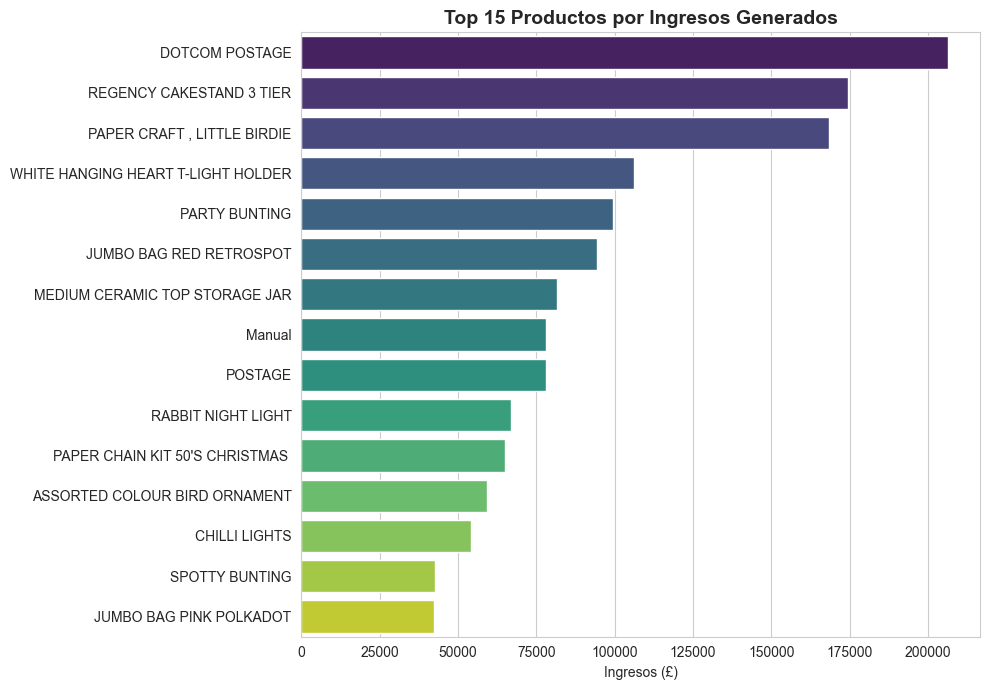

In [19]:
top_productos_ingresos = (
    df_ventas.groupby('Description')['ImporteTotal']
    .sum().sort_values(ascending=False).head(15)
)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_productos_ingresos.values, y=top_productos_ingresos.index, palette='viridis')
plt.title('Top 15 Productos por Ingresos Generados')
plt.xlabel('Ingresos (£)')
plt.ylabel('')
plt.tight_layout()
plt.show()


C:\Users\dhduq\AppData\Local\Temp\ipykernel_4660\3163407893.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_productos_unidades.values, y=top_productos_unidades.index, palette='mako')


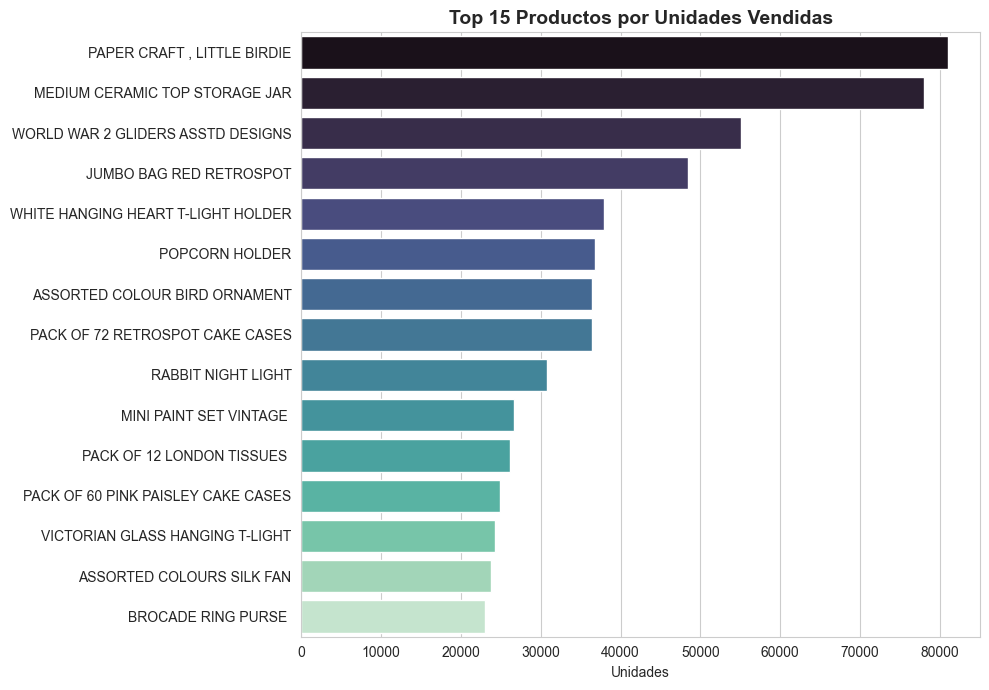

In [20]:
top_productos_unidades = (
    df_ventas.groupby('Description')['Quantity']
    .sum().sort_values(ascending=False).head(15)
)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_productos_unidades.values, y=top_productos_unidades.index, palette='mako')
plt.title('Top 15 Productos por Unidades Vendidas')
plt.xlabel('Unidades')
plt.ylabel('')
plt.tight_layout()
plt.show()


C:\Users\dhduq\AppData\Local\Temp\ipykernel_4660\4231469991.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_devoluciones.values, y=top_devoluciones.index, palette='rocket')


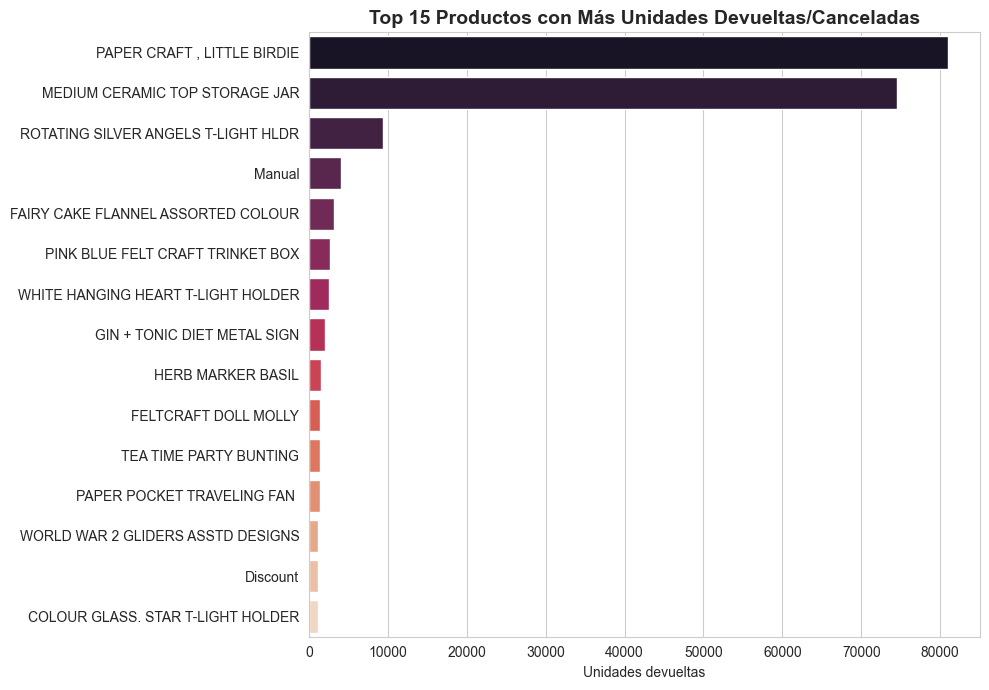

In [21]:
# Productos con más devoluciones (impacto en calidad / satisfacción)
top_devoluciones = (
    df_cancelado.groupby('Description')['Quantity']
    .sum().sort_values().head(15)  # más negativo = más devuelto
)
top_devoluciones = top_devoluciones.abs()

plt.figure(figsize=(10, 7))
sns.barplot(x=top_devoluciones.values, y=top_devoluciones.index, palette='rocket')
plt.title('Top 15 Productos con Más Unidades Devueltas/Canceladas')
plt.xlabel('Unidades devueltas')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 6. Análisis geográfico

¿Dónde están concentrados los ingresos? Esto ayuda a priorizar mercados para logística, marketing y expansión.


In [22]:
ventas_pais = df_ventas.groupby('Country').agg(
    Ingresos=('ImporteTotal', 'sum'),
    Pedidos=('InvoiceNo', 'nunique'),
    Clientes=('CustomerID', 'nunique')
).sort_values('Ingresos', ascending=False)

print(f"UK representa el {ventas_pais.loc['United Kingdom','Ingresos']/ingresos_totales*100:.1f}% de los ingresos totales")
ventas_pais.head(10)


UK representa el 84.6% de los ingresos totales


,Ingresos,Pedidos,Clientes
Country,,,
United Kingdom,"9,025,222.08",18019,3920
Netherlands,"285,446.34",94,9
EIRE,"283,453.96",288,3
Germany,"228,867.14",457,94
France,"209,715.11",392,87
Australia,"138,521.31",57,9
Spain,"61,577.11",90,30
Switzerland,"57,089.90",54,21
Belgium,"41,196.34",98,25


C:\Users\dhduq\AppData\Local\Temp\ipykernel_4660\1175145537.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_pais.head(10)['Ingresos'], y=ventas_pais.head(10).index, ax=axes[0], palette='crest')
C:\Users\dhduq\AppData\Local\Temp\ipykernel_4660\1175145537.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_paises_sin_uk['Ingresos'], y=top_paises_sin_uk.index, ax=axes[1], palette='flare')


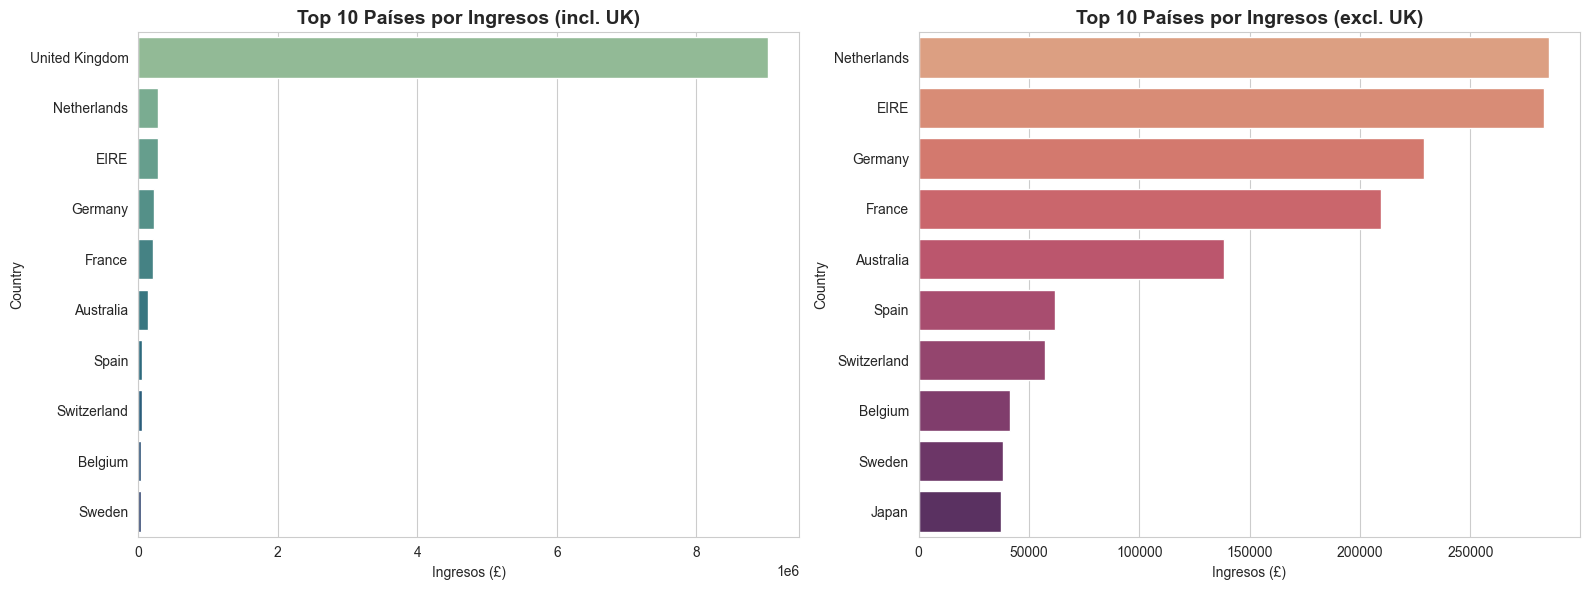

In [23]:
# Top países EXCLUYENDO Reino Unido (para ver oportunidades internacionales)
top_paises_sin_uk = ventas_pais.drop('United Kingdom').head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=ventas_pais.head(10)['Ingresos'], y=ventas_pais.head(10).index, ax=axes[0], palette='crest')
axes[0].set_title('Top 10 Países por Ingresos (incl. UK)')
axes[0].set_xlabel('Ingresos (£)')

sns.barplot(x=top_paises_sin_uk['Ingresos'], y=top_paises_sin_uk.index, ax=axes[1], palette='flare')
axes[1].set_title('Top 10 Países por Ingresos (excl. UK)')
axes[1].set_xlabel('Ingresos (£)')

plt.tight_layout()
plt.show()


## 7. Análisis de clientes: Segmentación RFM

**RFM (Recencia, Frecuencia, Monetario)** es una técnica estándar para segmentar clientes según:
- **Recencia**: días desde su última compra
- **Frecuencia**: número de pedidos realizados
- **Monetario**: total gastado

Esto permite identificar **clientes VIP, en riesgo de fuga, y de bajo valor**, para diseñar acciones comerciales específicas.


In [24]:
df_rfm_base = df_ventas.dropna(subset=['CustomerID']).copy()
fecha_referencia = df_rfm_base['InvoiceDate'].max() + timedelta(days=1)

rfm = df_rfm_base.groupby('CustomerID').agg(
    Recencia=('InvoiceDate', lambda x: (fecha_referencia - x.max()).days),
    Frecuencia=('InvoiceNo', 'nunique'),
    Monetario=('ImporteTotal', 'sum')
).reset_index()

print(f"Clientes analizados: {len(rfm):,}")
rfm.describe()


Clientes analizados: 4,338


,CustomerID,Recencia,Frecuencia,Monetario
count,"4,338.00","4,338.00","4,338.00","4,338.00"
mean,"15,300.41",92.54,4.27,"2,054.27"
std,"1,721.81",100.01,7.70,"8,989.23"
min,"12,346.00",1.00,1.00,3.75
25%,"13,813.25",18.00,1.00,307.41
50%,"15,299.50",51.00,2.00,674.49
75%,"16,778.75",142.00,5.00,"1,661.74"
max,"18,287.00",374.00,209.00,"280,206.02"


In [25]:
# Scoring RFM (quintiles 1-5, 5 = mejor)
rfm['R_Score'] = pd.qcut(rfm['Recencia'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frecuencia'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetario'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segmentar(row):
    if row['RFM_Score'] >= 13:
        return 'Campeones'
    elif row['RFM_Score'] >= 10:
        return 'Clientes Leales'
    elif row['RFM_Score'] >= 7:
        return 'Potenciales'
    elif row['RFM_Score'] >= 5:
        return 'En Riesgo'
    else:
        return 'Perdidos / Bajo Valor'

rfm['Segmento'] = rfm.apply(segmentar, axis=1)
rfm['Segmento'].value_counts()


Segmento
Potenciales              1092
Clientes Leales          1008
Campeones                 934
En Riesgo                 759
Perdidos / Bajo Valor     545
Name: count, dtype: int64

In [26]:
resumen_segmentos = rfm.groupby('Segmento').agg(
    Clientes=('CustomerID', 'count'),
    IngresoPromedio=('Monetario', 'mean'),
    IngresoTotal=('Monetario', 'sum'),
    FrecuenciaPromedio=('Frecuencia', 'mean'),
    RecenciaPromedio=('Recencia', 'mean')
).sort_values('IngresoTotal', ascending=False)

resumen_segmentos['% Ingresos'] = resumen_segmentos['IngresoTotal'] / resumen_segmentos['IngresoTotal'].sum() * 100
resumen_segmentos


,Clientes,IngresoPromedio,IngresoTotal,FrecuenciaPromedio,RecenciaPromedio,% Ingresos
Segmento,,,,,,
Campeones,934,"6,697.36","6,255,336.53",11.74,14.61,70.19
Clientes Leales,1008,"1,397.45","1,408,629.91",3.86,43.42,15.81
Potenciales,1092,808.25,"882,612.66",2.01,85.43,9.90
En Riesgo,759,342.40,"259,877.89",1.23,147.27,2.92
Perdidos / Bajo Valor,545,192.57,"104,950.91",1.01,254.93,1.18


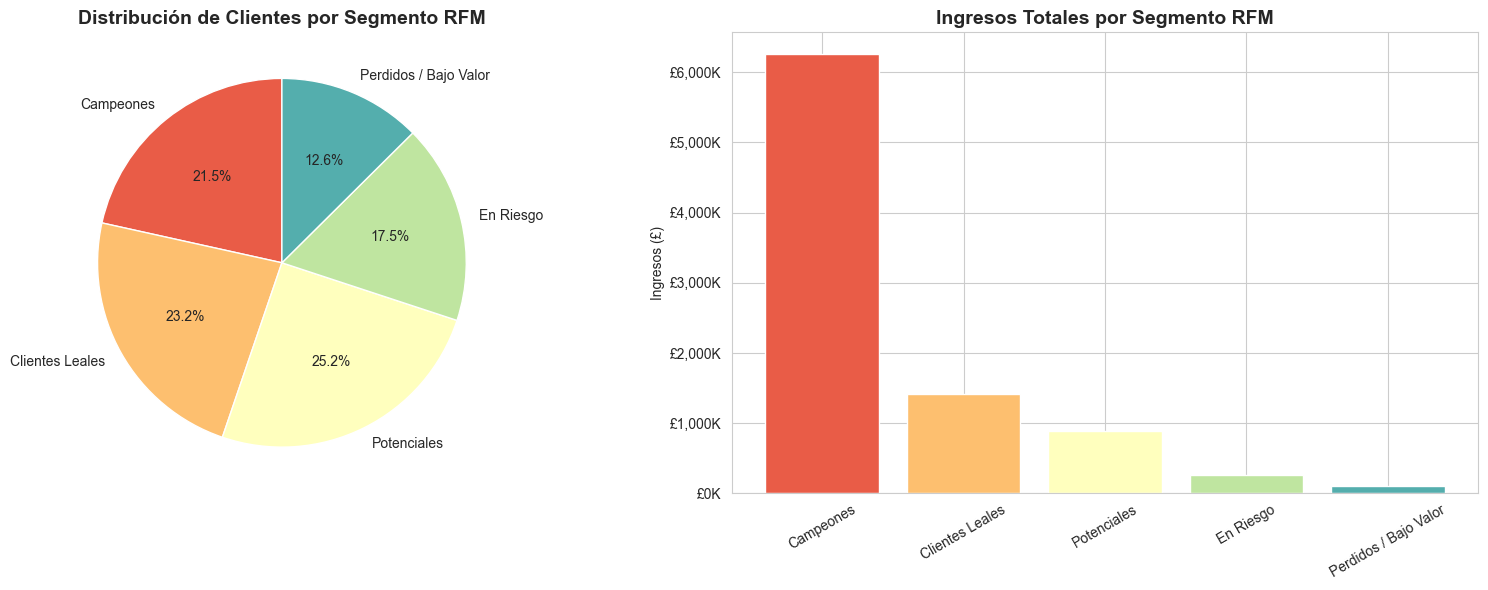

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

orden_seg = resumen_segmentos.index
colores = sns.color_palette('Spectral', len(orden_seg))

axes[0].pie(resumen_segmentos['Clientes'], labels=orden_seg, autopct='%1.1f%%',
            colors=colores, startangle=90)
axes[0].set_title('Distribución de Clientes por Segmento RFM')

axes[1].bar(orden_seg, resumen_segmentos['IngresoTotal'], color=colores)
axes[1].set_title('Ingresos Totales por Segmento RFM')
axes[1].set_ylabel('Ingresos (£)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'£{x/1000:,.0f}K'))

plt.tight_layout()
plt.show()


El 26.1% de los clientes (1,132) genera el 80% de los ingresos


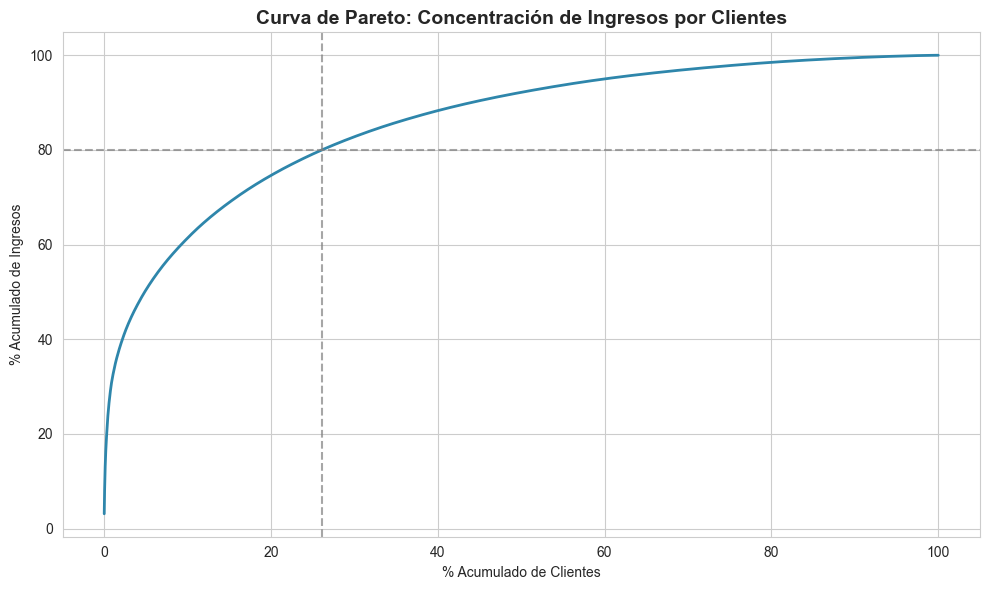

In [28]:
# Regla 80/20 (Pareto): ¿qué % de clientes genera el 80% de los ingresos?
rfm_sorted = rfm.sort_values('Monetario', ascending=False).reset_index(drop=True)
rfm_sorted['IngresoAcumulado'] = rfm_sorted['Monetario'].cumsum()
rfm_sorted['%AcumuladoIngreso'] = rfm_sorted['IngresoAcumulado'] / rfm_sorted['Monetario'].sum() * 100
rfm_sorted['%AcumuladoClientes'] = (rfm_sorted.index + 1) / len(rfm_sorted) * 100

clientes_80pct = (rfm_sorted['%AcumuladoIngreso'] <= 80).sum()
print(f"El {clientes_80pct/len(rfm_sorted)*100:.1f}% de los clientes ({clientes_80pct:,}) genera el 80% de los ingresos")

plt.figure(figsize=(10, 6))
plt.plot(rfm_sorted['%AcumuladoClientes'], rfm_sorted['%AcumuladoIngreso'], color='#2E86AB', linewidth=2)
plt.axhline(80, color='gray', linestyle='--', alpha=0.7)
plt.axvline(clientes_80pct/len(rfm_sorted)*100, color='gray', linestyle='--', alpha=0.7)
plt.title('Curva de Pareto: Concentración de Ingresos por Clientes')
plt.xlabel('% Acumulado de Clientes')
plt.ylabel('% Acumulado de Ingresos')
plt.tight_layout()
plt.show()


## 8. Clientes con mayor valor (Top 10)


In [29]:
top_clientes = rfm.sort_values('Monetario', ascending=False).head(10)[
    ['CustomerID', 'Monetario', 'Frecuencia', 'Recencia', 'Segmento']
].reset_index(drop=True)
top_clientes.columns = ['CustomerID', 'Ingreso Total (£)', 'N° Pedidos', 'Días desde última compra', 'Segmento']
top_clientes


,CustomerID,Ingreso Total (£),N° Pedidos,Días desde última compra,Segmento
0,"14,646.00","280,206.02",73,2,Campeones
1,"18,102.00","259,657.30",60,1,Campeones
2,"17,450.00","194,550.79",46,8,Campeones
3,"16,446.00","168,472.50",2,1,Campeones
4,"14,911.00","143,825.06",201,1,Campeones
5,"12,415.00","124,914.53",21,24,Campeones
6,"14,156.00","117,379.63",55,10,Campeones
7,"17,511.00","91,062.38",31,3,Campeones
8,"16,029.00","81,024.84",63,39,Campeones
9,"12,346.00","77,183.60",1,326,Potenciales


## 9. Conclusiones y recomendaciones estratégicas

**Hallazgos clave:**

1. **Concentración geográfica**: el Reino Unido domina las ventas; los demás países representan una oportunidad de expansión internacional aún poco explotada.
2. **Concentración de clientes (Pareto)**: una minoría de clientes genera la mayoría de los ingresos → priorizar retención y fidelización de los segmentos "Campeones" y "Clientes Leales".
3. **Clientes "En Riesgo" / "Perdidos"**: representan una oportunidad de recuperación mediante campañas de reactivación (email marketing, descuentos personalizados).
4. **Estacionalidad**: existen picos de ventas en ciertos meses (ej. previo a fin de año) — clave para planificación de inventario y campañas.
5. **Productos estrella**: un grupo reducido de SKUs concentra gran parte de los ingresos y unidades vendidas — asegurar su disponibilidad en stock.
6. **Devoluciones/cancelaciones**: representan un porcentaje relevante de los pedidos — revisar calidad, descripción de producto o proceso logístico de los artículos con más devoluciones.

**Recomendaciones de acción:**

- 🎯 Diseñar programas de fidelización dirigidos a clientes "Campeones" y "Leales" (mayor ROI de marketing).
- 📧 Lanzar campañas de reactivación (win-back) para clientes "En Riesgo" y "Perdidos", antes de que abandonen definitivamente.
- 🌍 Evaluar estrategias de expansión en los países con mayor potencial fuera de UK (ej. mejorar logística/checkout localizado).
- 📦 Asegurar stock prioritario de los productos top, y revisar causas de devolución en los productos con más unidades devueltas.
- 📅 Planificar campañas y stock con anticipación en los meses de mayor demanda histórica.
- 💰 Monitorear el ticket promedio y explorar estrategias de *upsell/cross-sell* para incrementarlo.

---
*Notebook generado a partir del dataset `Online_Retail.xlsx`.*
